<a href="https://colab.research.google.com/github/TienNguyen0712/hybrid-llm-tabular-pipeline-for-icu-mortality-prediction/blob/main/notebooks/predict_mortality_using_mimic_iv_baseline_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Xây dựng mô hình dự đoán tử vong trong đợt nằm viện, sử dụng dữ liệu 24h đầu ICU từ MIMIC-IV (BaseLine1)**

**Mục tiêu:**

Notebook này thực hiện xây dựng một mô hình dự đoán tỷ lệ tử vong từ bảng MIMIC bằng các mô hình học máy. Nhằm tạo ra một chuẩn dữ liệu để so sánh với các kỹ thuật khác trong tương lai (nếu có)

**Bộ dữ liệu**

MIMIC-IV là cơ sở dữ liệu lớn gồm các bảng về thông tin bệnh nhân, lâm sàng, các thủ thuật, v...

Lý do chọn bộ dữ liệu này do tính phức tạp, sát với dữ liệu thực tế, việc xử lý dữ liệu này là một trong những bước khó khắn, ...

- 2 module chính được sử dụng trong notebook này chính là `hosp` và `icu`. Chi tiết các bảng lựa chọn sẽ được mô tả ở dưới


## **1. Nạp thư viện và dữ liệu cần thiết**

In [1]:
# Bỏ comment nếu chạy trên Google Colab
from google.colab import drive
drive.mount('/content/drive')
!pip install tableone pyarrow seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import gc
import warnings
warnings.filterwarnings('ignore')

import os
from typing import List, Tuple, Dict, Optional

# Cài đặt style biểu đồ chuyên nghiệp
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_style("whitegrid")
print("✓ Libraries loaded")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
✓ Libraries loaded


In [2]:
import pyarrow as pa
import pyarrow.csv as pv
import pyarrow.parquet as pq

def convert_csv_to_parquet_batch(
    table_configs,
    input_dir,
    output_dir,
    folder,
    block_size=100_000_000,
    compression='snappy'
):
    """
    Chuyển đổi danh sách các bảng csv.gz sang Parquet phân theo module.
    """
    # Ghép folder vào đường dẫn output_dir
    target_output_dir = os.path.join(output_dir, folder)
    target_input_dir = os.path.join(input_dir, folder)

    os.makedirs(target_output_dir, exist_ok=True)
    read_options = pv.ReadOptions(block_size=block_size)

    print(f"ĐANG XỬ LÝ MODULE: [{folder.upper()}]")


    for filename, columns in table_configs.items():
        input_file_path = os.path.join(target_input_dir, filename)

        # Lưu kết quả vào đúng thư mục con của module đó
        output_filename = filename.replace('.csv.gz', '.parquet').replace('.csv', '.parquet')
        output_file_path = os.path.join(target_output_dir, output_filename)

        print(f"\n- Đang xử lý: {filename}")
        print(f"  + Nguồn: {input_file_path}")
        print(f"  + Đích:  {output_file_path}")

        if not os.path.exists(input_file_path):
            print(f"Cảnh báo: Không tìm thấy file '{input_file_path}'. Đang bỏ qua...")
            continue

        convert_options = pv.ConvertOptions(include_columns=columns) if columns else pv.ConvertOptions()

        try:
            reader = pv.open_csv(
                input_file_path,
                read_options=read_options,
                convert_options=convert_options
            )

            writer = None
            for i, batch in enumerate(reader):
                table = pa.Table.from_batches([batch])

                if writer is None:
                    writer = pq.ParquetWriter(output_file_path, table.schema, compression=compression)

                writer.write_table(table)
                print(f"   -> [{filename}] Đã ghi batch {i + 1}...")

            if writer:
                writer.close()
                print(f"Hoàn thành: {output_filename}")
            else:
                print(f"File rỗng hoặc không có dữ liệu.")

        except Exception as e:
            print(f"Lỗi trong quá trình xử lý file {filename}: {e}")

    print(f"\nĐã hoàn thành toàn bộ bảng trong module [{folder.upper()}]!")

In [ ]:
# # Đường dẫn gốc đến dữ liệu nguồn và dữ liệu đích
# BASE_INPUT_DIR = '/content/drive/MyDrive/NCKH-DDU1231/physionet.org/mimiciv/3.1'
# BASE_OUTPUT_DIR = '/content/drive/MyDrive/NCKH-DDU1231/outputs_parquet'

# BLOCK_SIZE = 100_000_000  # 100MB cho mỗi batch đọc
# COMPRESSION = 'snappy'

# # ĐỊNH NGHĨA CÁC MODULE VÀ BẢNG TƯƠNG ỨNG
# MODULE_CONFIGS = {
#     'icu': {
#         'chartevents.csv.gz': [
#             'subject_id', 'hadm_id', 'stay_id',
#             'charttime', 'itemid', 'valuenum',
#             'value', 'valueuom'
#         ],

#         'inputevents.csv.gz': None,
#         'outputevents.csv.gz': None,
#         'procedureevents.csv.gz': None,
#         'icustays.csv.gz': None,
#     },

#     'hosp': {
#         'patients.csv.gz': [
#             'subject_id', 'gender', 'anchor_age'
#         ],

#         'admissions.csv.gz': None,

#         'labevents.csv.gz': [
#             'subject_id', 'hadm_id',
#             'charttime', 'itemid', 'valuenum',
#             'value', 'valueuom'
#         ]
#     }
# }

In [ ]:
# for folder_name, table_configs in MODULE_CONFIGS.items():
#         convert_csv_to_parquet_batch(
#             table_configs=table_configs,
#             input_dir=BASE_INPUT_DIR,
#             output_dir=BASE_OUTPUT_DIR,
#             folder=folder_name,
#             block_size=BLOCK_SIZE,
#             compression=COMPRESSION
#         )

# print("\nTẤT CẢ CÁC MODULE ĐÃ ĐƯỢC CHUYỂN ĐỔI THÀNH CÔNG!")

In [3]:
# Đường dẫn gốc tới thư mục chứa dữ liệu Parquet
DATA_DIR = '/content/drive/MyDrive/NCKH-DDU1231/outputs_parquet'

def load(folder, name, columns=None):
    """
    Nạp dữ liệu từ file Parquet.

    :param folder: Tên module (vd: 'icu', 'hosp', 'ed')
    :param name: Tên file (vd: 'chartevents.parquet' hoặc 'chartevents')
    :param columns: Danh sách các cột cần lấy (mặc định None - lấy tất cả).
                    Đọc cột chọn lọc với Parquet giúp tiết kiệm đáng kể RAM.
    """
    path = os.path.join(DATA_DIR, folder, name)

    if os.path.exists(path):
        # pd.read_parquet hỗ trợ đọc chỉ các cột cần thiết qua tham số columns
        df = pd.read_parquet(path, columns=columns)
        print(f"  ✓ {folder}/{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    else:
        print(f"  ✗ {folder}/{name}: KHÔNG TÌM THẤY (Đường dẫn: {path})")
        return pd.DataFrame()

## **2. Tiền xử lý dữ liệu trước khi chia huấn luyện**

### **2.1. Xây dựng tập cohort**

Cohort được xây dựng bám sát theo các tiêu chí như sau:
- Phải là người trưởng thành (anchor_age > 18)
- Thời gian nằm ICU phải trên 24h (LOS >= 24)
- Chỉ lấy lần nhập ICU đầu tiên trong một lần nhập viện
- Loại các bệnh nhân đã tử vong, xuât hoặc chuyển viện trong vòng 24h đầu

In [4]:
def build_and_val_icu_cohort(patients_df: pd.DataFrame, admissions_df: pd.DataFrame, icustays_df: pd.DataFrame) -> pd.DataFrame:
  # Chuyển đổi định dạng mốc thời gian sang Datetime
  time_cols = {
      'icustays_df': ['intime', 'outtime'],
      'admissions_df': ['admittime', 'dischtime', 'edregtime', 'edouttime'],
      'patients_df' : []
  }

  for col in time_cols['icustays_df']:
        icustays_df[col] = pd.to_datetime(icustays_df[col])
  for col in time_cols['admissions_df']:
        admissions_df[col] = pd.to_datetime(admissions_df[col])
  # 1. Inner Join với patients
  cohort = icustays_df.merge(
  admissions_df[["subject_id", "hadm_id", "admittime", "dischtime", "admission_type",
                        "admission_location", "deathtime",
                        "hospital_expire_flag"]],
          on=['subject_id', 'hadm_id'],
          how='inner'
      )
  # 2. Inner join với admission
  cohort = cohort.merge(
          patients_df[["subject_id", "gender", "anchor_age"]],
          on='subject_id',
          how='inner'
      )

  initial_count = len(cohort)
  print(f"Tổng số lượt ICU ban đầu: {initial_count:,}")

  # Áp dụng các tiêu chí lọc
  # ---------------------------------------------
  # Tiêu chí 1: Người trưởng thành (>= 18 tuổi)
  # ----------------------------------------------
  cohort = cohort[cohort["anchor_age"] >= 18]
  print(f"-> Sau khi lọc người trưởng thành (>=18t): {len(cohort):,} ca")

  # ---------------------------------------------
  # Tiêu chí 2: Lấy ca ICU đầu tiên của mỗi bệnh nhân (First ICU stay per patient)
  # Sắp xếp theo intime để chắc chắn lấy ca đầu tiên trong đời/lịch sử của bệnh nhân
  # ----------------------------------------------
  cohort = (
      cohort.sort_values(["subject_id", "intime"])
            .groupby("subject_id", as_index=False)
            .first()
  )

  print(f"-> Sau khi chỉ lấy ca ICU đầu tiên của mỗi bệnh nhân: {len(cohort):,} ca")

  # Tính thời gian nằm ICU (tính theo ngày)
  cohort["icu_los_days"] = (
      pd.to_datetime(cohort["outtime"]) - pd.to_datetime(cohort["intime"])
  ).dt.total_seconds() / 86400
  cohort["icu_los_hours"] = cohort["icu_los_days"] * 24

  # ---------------------------------------------
  # Tiêu chí 3: ICU stay trên 1 ngày (>= 1 ngày, tức >= 24 giờ)
  # ---------------------------------------------
  cohort = cohort[cohort["icu_los_days"] >= 1.0]
  print(f"-> Sau khi lọc ICU stay > 1 ngày: {len(cohort):,} ca")

  # Tạo mốc thời gian kết thúc cửa sổ quan sát (intime + 24h)
  cohort['obs_end_time'] = cohort['intime'] + pd.Timedelta(hours=24)

  print("=== BẮT ĐẦU THỰC HIỆN Kiểm tra logic ===")
  """
  Tiêu chí loại bỏ các lượt ICU vi phạm logic:
  - Tiêu chí 1: Các khóa phải là duy nhất
  - Tiêu chí 2: Kiểm tra thứ tự các môc thời gian logic
    - Thời gian nhập viện <= Thời gian vào ICU < Thời gian vào ICU + 24h <= Thời gian ra ICU <= Thời gian ra viện
  - Tiêu chí 3: Kiểm tra tính hợp lệ của Nhãn Mục tiêu
    - Thời điểm tử vong của bệnh nhân phải lớn hơn thười gian vào ICU + 24h

  """

  # List lưu giữ các stay_id vi phạm cần loại bỏ
  invalid_stay_ids = set()

  # Check 1: Kiểm tra tính duy nhất của Khóa
  total_rows = len(cohort)
  unique_stays = cohort['stay_id'].nunique()
  print(f"Tổng số dòng: {total_rows} | Số stay_id duy nhất: {unique_stays}")
  if total_rows != unique_stays:
      print("Bị trùng lặp stay_id do phép Join! Cần loại bỏ bản ghi trùng.")
      cohort = cohort.drop_duplicates(subset=['stay_id'])

  # Check 2: Kiểm tra thứ tự mốc thời gian logic
  invalid_time_mask = (
        (cohort['admittime'] > cohort['intime']) |
        (cohort['intime'] >= cohort['outtime']) |
        (cohort['outtime'] > cohort['dischtime'])
    )
  time_faulty_ids = cohort[invalid_time_mask]['stay_id'].tolist()
  invalid_stay_ids.update(time_faulty_ids)
  print(f"Phát hiện {len(time_faulty_ids)} lượt ICU vi phạm thứ tự thời gian sinh lý.")

  # Check 3: Kiểm tra tính hợp lệ của Nhãn Mục tiêu
  early_death_mask = (
        (cohort['hospital_expire_flag'] == 1) &
        (cohort['deathtime'].notna()) &
        (cohort['deathtime'] <= cohort['obs_end_time'])
    )
  early_death_ids = cohort[early_death_mask]['stay_id'].tolist()
  invalid_stay_ids.update(early_death_ids)
  print(f"Phát hiện {len(early_death_ids)} bệnh nhân tử vong TRƯỚC/TRONG 24h đầu ICU.")

  # Loai bỏ các bản ghi vi phạm khỏi Cohort chính thức
  clean_cohort = cohort[~cohort['stay_id'].isin(invalid_stay_ids)].reset_index(drop=True)

  print("=== BẮT ĐẦU THỰC HIỆN TIỀN XỬ LÝ ===")
  """
  Các bước thực hiện:
  - Loại bỏ các cột không dùng đến
  - Chuyển đổi dạng dữ liệu
  - Đổi tên cột
  """
  clean_cohort["Outcome"]   = clean_cohort["hospital_expire_flag"].astype(int) # Chuyển biến outcome về dạng nhị phân (0/1)
  clean_cohort["Sex"]       = (clean_cohort["gender"] == "M").astype(int) # Chuyển biến giới tính về dạng nhị phân (0/1)
  clean_cohort["LOS_hours"] = clean_cohort["los"].astype(float) * 24 # Tạo biến los - giờ nằm icu

  clean_cohort = clean_cohort.rename(columns={
          "subject_id": "PatientID", "hadm_id": "AdmissionID", # Đổi mã bệnh nhân,  mã lần nhập viện
          "stay_id": "StayID",       "intime":  "ICUInTime", # Đổi mã nằm icu, thời gian vào ICU
          "outtime": "ICUOutTime",   "anchor_age": "Age", # Đổi thời gian ra icu, tuổi bệnh nhân
          "admission_type": "AdmissionType"
      })[["PatientID", "AdmissionID", "StayID",
          "ICUInTime", "ICUOutTime",
          "Age", "Sex", "AdmissionType", "Outcome", "LOS_hours"]].reset_index(drop=True) # Lấy các đặc trưng cần lấy

  print(f"=== KHỞI TẠO COHORT THÀNH CÔNG ===")
  print(f"Số lượng bệnh nhân hợp lệ cuối cùng: {len(clean_cohort)}")
  print(f"Thời gian nằm ICU trung bình: {cohort['icu_los_days'].mean():.2f} ngày")
  print(f"Tỷ lệ tử vong (Mortality Rate): {clean_cohort['Outcome'].mean():.2%}")

  return clean_cohort


In [ ]:
print("Loading core tables...")
patients   = load("hosp", "patients.parquet")      # Thông tin bệnh nhân
admissions = load("hosp", "admissions.parquet")    # Thông tin nhập viện
icustays   = load("icu",  "icustays.parquet")      # Thông tin lần nằm

cohort = build_and_val_icu_cohort(patients, admissions, icustays)

Loading core tables...
  ✓ hosp/patients.parquet: 364,627 rows × 3 cols
  ✓ hosp/admissions.parquet: 546,028 rows × 16 cols
  ✓ icu/icustays.parquet: 94,458 rows × 8 cols
Tổng số lượt ICU ban đầu: 94,458
-> Sau khi lọc người trưởng thành (>=18t): 94,458 ca
-> Sau khi chỉ lấy ca ICU đầu tiên của mỗi bệnh nhân: 65,366 ca
-> Sau khi lọc ICU stay > 1 ngày: 51,839 ca
=== BẮT ĐẦU THỰC HIỆN Kiểm tra logic ===
Tổng số dòng: 51839 | Số stay_id duy nhất: 51839
Phát hiện 8714 lượt ICU vi phạm thứ tự thời gian sinh lý.
Phát hiện 171 bệnh nhân tử vong TRƯỚC/TRONG 24h đầu ICU.
=== BẮT ĐẦU THỰC HIỆN TIỀN XỬ LÝ ===
=== KHỞI TẠO COHORT THÀNH CÔNG ===
Số lượng bệnh nhân hợp lệ cuối cùng: 43124
Thời gian nằm ICU trung bình: 4.26 ngày
Tỷ lệ tử vong (Mortality Rate): 4.39%


In [ ]:
cohort.isna().sum()

,0
PatientID,0
AdmissionID,0
StayID,0
ICUInTime,0
ICUOutTime,0
Age,0
Sex,0
AdmissionType,0
Outcome,0
LOS_hours,0


In [ ]:
cohort.columns

Index(['PatientID', 'AdmissionID', 'StayID', 'ICUInTime', 'ICUOutTime', 'Age',
       'Sex', 'AdmissionType', 'Outcome', 'LOS_hours'],
      dtype='object')

In [ ]:
cohort.head()

,PatientID,AdmissionID,StayID,ICUInTime,ICUOutTime,Age,Sex,AdmissionType,Outcome,LOS_hours
0,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17,86,0,EW EMER.,0,93.438056
1,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00,55,0,EW EMER.,0,26.832778
2,10001725,25563031,31205490,2110-04-11 15:52:22,2110-04-12 23:59:56,46,0,EW EMER.,0,32.126111
3,10002013,23581541,39060235,2160-05-18 10:00:53,2160-05-19 17:33:33,53,0,SURGICAL SAME DAY ADMISSION,0,31.544444
4,10002114,27793700,34672098,2162-02-17 23:30:00,2162-02-20 21:16:27,56,1,OBSERVATION ADMIT,0,69.774167


## **3. Xây dựng các bảng đặc trưng thực hiện tiền xử lý cho dữ liệu huấn luyện**

In [ ]:
from typing import Dict, Tuple, List
import shutil

In [ ]:
VALID_RANGE = {
    "HR": (10, 300), "RR": (2, 80), "Temp_C": (25, 45), "Temp_F": (77, 113), "SBP": (30, 300), "DBP": (10, 200), "MBP": (20, 250), "SpO2": (50, 100),
    "GCS_total": (3, 15), "WBC": (0.1, 500), "HCT": (5, 70), "PLT": (1, 3000), "pH": (6.5, 8.5), "FiO2": (0.1, 1.05), "PaO2": (10, 700), "PaCO2": (10, 200),
    "HCO3": (5, 60), "CKMB": (0, 10000), "BNP": (1, 50000), "AST": (1, 50000), "ALT": (1, 50000), "Bili_total": (0.1, 100), "Bili_direct": (0.1, 100),
    "DDimer": (0.1, 100000), "BUN": (1, 500), "Creatinine": (0.1, 50), "Cortisol": (0.1, 200), "Na": (100, 180), "K": (1, 10), "Cl": (70, 150),
    "Mg": (0.5, 10), "Glucose": (10, 2000), "Height": (50, 250), "Weight": (10, 400), "WBC_lab": (0.1, 500), "HCT_lab": (5, 70), "PLT_lab": (1, 3000),
    "pH_lab": (6.5, 8.5), "PaO2_lab": (10, 700), "PaCO2_lab": (10, 200), "HCO3_lab": (5, 60), "Creatinine_lab": (0.1, 50), "BUN_lab": (1, 500),
    "Albumin_lab": (0.5, 8), "Lactate_lab": (0.1, 30), "CRP_lab": (0, 500), "Ca_lab": (3, 20), "Na_lab": (100, 180), "K_lab": (1, 10), "Cl_lab": (70, 150), "Mg_lab": (0.5, 10),
}

### **3.1. Xây dựng bảng chart vitals từ `chartevent`**

Kết hợp với bảng cohort với cửa số được lấy trong vòng 24h khi nằm ở icu
- intime <= charttime <= intime + 24h
- Lọc các chỉ số theo mã id hợp lệ rồi học các giá trị ngoại lai
- Thực hiện sinh thêm các đặc trưng mới với các chỉ số phức tạp
- Chuyển đổi dơn vị về chuẩn chung

In [ ]:
CHART_ITEM2VAR = {
    220045: "HR", 220210: "RR", 224690: "RR", 224422: "RR",
    223761: "Temp_F", 223762: "Temp_C",
    220179: "SBP", 220050: "SBP", 220180: "DBP", 220051: "DBP", 220052: "MBP", 220181: "MBP",
    220277: "SpO2",
    220739: "GCS_eye", 223901: "GCS_motor", 223900: "GCS_verbal",
    223835: "FiO2",
    220621: "Glucose",
    226512: "Weight_kg", 226531: "Weight_lbs"
}

GCS_EYE_MAP = {"None": 0, "1 No Response": 1, "2 To pain": 2, "To Pain": 2, "3 To speech": 3, "To Speech": 3, "4 Spontaneously": 4, "Spontaneously": 4}
GCS_MOTOR_MAP = {"1 No Response": 1, "No response": 1, "2 Abnorm extensn": 2, "Abnormal extension": 2, "3 Abnorm flexion": 3, "Abnormal Flexion": 3, "4 Flex-withdraws": 4, "Flex-withdraws": 4, "5 Localizes Pain": 5, "Localizes Pain": 5, "6 Obeys Commands": 6, "Obeys Commands": 6}
GCS_VERBAL_MAP = {
    "No Response": 1, "1 No Response": 1,
    "2 Incomp sounds": 2, "Incomprehensible sounds": 2,
    "3 Inapprop words": 3, "Inappropriate Words": 3,
    "4 Confused": 4, "Confused": 4,
    "5 Oriented": 5, "Oriented": 5,
    # Bệnh nhân đặt NKQ/mở khí quản: KHÔNG map thành điểm số cố định
    "No Response-ETT": np.nan, "1.0 ET/Trach": np.nan,
}

# Track riêng cờ "đang đặt NKQ tại thời điểm đo GCS" — dùng chung với biến Ventilated đã có sẵn
# Với GCS_total, khi verbal = NaN do đặt NKQ, một cách làm phổ biến (theo SOFA/APACHE convention)
# là ước lượng verbal dựa trên eye+motor, hoặc đơn giản nhất là loại điểm verbal ra khỏi tổng
# và ghi chú rõ trong tài liệu rằng GCS_total ở nhóm bệnh nhân thở máy là ước lượng dưới (underestimate)

CHART_FEATURES = ["HR", "RR", "Temp_C", "SBP", "DBP", "MBP", "SpO2", "GCS_total", "FiO2", "Glucose", "Weight", "GCS_verbal_intubated"]

In [ ]:
def process_chartevents(data_dir, cohort, hours=24, output_path=None, chunksize=1_000_000):
    print(f"Đang xử lý chartevents (Parquet) theo chunk (chunksize={chunksize})...")

    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    valid_stays = set(cohort["StayID"].tolist())
    valid_items = set(CHART_ITEM2VAR.keys())

    file_path = os.path.join(data_dir, "icu", "chartevents.parquet")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    temp_dir = os.path.join(data_dir, "temp_chartevents_chunks")
    os.makedirs(temp_dir, exist_ok=True)
    chunk_files = []

    intubated_verbal_codes = {"No Response-ETT", "1.0 ET/Trach"}

    try:
        parquet_file = pq.ParquetFile(file_path)
        cols = ["subject_id", "hadm_id", "stay_id", "charttime", "itemid", "value", "valuenum"]

        for i, batch in enumerate(parquet_file.iter_batches(batch_size=chunksize, columns=cols)):
            chunk = batch.to_pandas()

            # Lọc sơ bộ stay_id và itemid
            chunk = chunk[chunk["stay_id"].isin(valid_stays) & chunk["itemid"].isin(valid_items)]
            if chunk.empty:
                continue

            # Tính toán thời gian & Lọc giờ nhập ICU
            chunk["icu_intime"] = chunk["stay_id"].map(stay2intime)
            chunk["charttime"] = pd.to_datetime(chunk["charttime"])
            chunk["hours_in"] = (chunk["charttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600.0

            chunk = chunk[(chunk["hours_in"] >= 0) & (chunk["hours_in"] < hours)].copy()
            if chunk.empty:
                continue

            chunk["Variable"] = chunk["itemid"].map(CHART_ITEM2VAR)
            chunk["hour_bucket"] = chunk["hours_in"].astype(int).clip(0, hours - 1)

            # --- THÊM: Xử lý gcs_verbal_intubated ---
            # Tạo các dòng riêng cho biến gcs_verbal_intubated để đồng bộ quy trình gom nhóm
            is_intubated = (chunk["Variable"] == "GCS_verbal") & chunk["value"].isin(intubated_verbal_codes)
            if is_intubated.any():
                intubated_rows = chunk[is_intubated].copy()
                intubated_rows["Variable"] = "gcs_verbal_intubated"
                intubated_rows["valuenum"] = 1.0
                chunk = pd.concat([chunk, intubated_rows], ignore_index=True)

            # Ánh xạ điểm GCS thành phần sang dạng số
            for var, mapping in [("GCS_eye", GCS_EYE_MAP), ("GCS_motor", GCS_MOTOR_MAP), ("GCS_verbal", GCS_VERBAL_MAP)]:
                m = chunk["Variable"] == var
                if m.any():
                    chunk.loc[m, "valuenum"] = chunk.loc[m, "value"].map(mapping)

            # Ép kiểu số
            chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")

            # Chuyển đổi đơn vị
            m = chunk["Variable"] == "Temp_F"
            if m.any():
                chunk.loc[m, "valuenum"] = (chunk.loc[m, "valuenum"] - 32.0) * 5.0 / 9.0
                chunk.loc[m, "Variable"] = "Temp_C"

            m = chunk["Variable"] == "Weight_lbs"
            if m.any():
                chunk.loc[m, "valuenum"] = chunk.loc[m, "valuenum"] * 0.45359237
                chunk.loc[m, "Variable"] = "Weight"
            chunk.loc[chunk["Variable"] == "Weight_kg", "Variable"] = "Weight"

            m = chunk["Variable"] == "Height_in"
            if m.any():
                chunk.loc[m, "valuenum"] = chunk.loc[m, "valuenum"] * 2.54
                chunk.loc[m, "Variable"] = "Height"
            chunk.loc[chunk["Variable"] == "Height_cm", "Variable"] = "Height"

            # Lọc Outliers an toàn
            chunk = chunk.dropna(subset=["valuenum"])
            if 'VALID_RANGE' in globals() and VALID_RANGE is not None:
                for feat, (lo, hi) in VALID_RANGE.items():
                    m = chunk["Variable"] == feat
                    if m.any():
                        outlier_mask = m & ((chunk["valuenum"] < lo) | (chunk["valuenum"] > hi))
                        chunk.loc[outlier_mask, "valuenum"] = np.nan

            chunk = chunk.dropna(subset=["valuenum"])
            if chunk.empty:
                continue

            # Gom nhóm cục bộ
            local_agg = (
                chunk.groupby(["subject_id", "hadm_id", "stay_id", "hour_bucket", "Variable"])["valuenum"]
                .agg(val_sum="sum", val_count="count")
                .reset_index()
            )

            chunk_file = os.path.join(temp_dir, f"chunk_{i}.parquet")
            local_agg.to_parquet(chunk_file, index=False)
            chunk_files.append(chunk_file)

        if not chunk_files:
            print("Không tìm thấy dữ liệu phù hợp!")
            return pd.DataFrame(columns=["PatientID", "AdmissionID", "StayID", "hour_bucket"] + CHART_FEATURES)

        # Tổng hợp toàn cục
        all_chunks = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)

        global_agg = (
            all_chunks.groupby(["subject_id", "hadm_id", "stay_id", "hour_bucket", "Variable"])
            .agg(total_sum=("val_sum", "sum"), total_count=("val_count", "sum"))
            .reset_index()
        )

        # Với biến nhị phân gcs_verbal_intubated thì lấy max (1 nếu có ít nhất 1 lần ghi nhận trong giờ đó)
        is_intubated_var = global_agg["Variable"] == "gcs_verbal_intubated"
        global_agg["valuenum"] = global_agg["total_sum"] / global_agg["total_count"]
        global_agg.loc[is_intubated_var, "valuenum"] = 1.0

        # Pivot sang Wide Format
        wide = global_agg.pivot_table(
            index=["subject_id", "hadm_id", "stay_id", "hour_bucket"],
            columns="Variable",
            values="valuenum"
        ).reset_index()

        wide.columns.name = None
        wide = wide.rename(columns={"subject_id": "PatientID", "stay_id": "StayID", "hadm_id": "AdmissionID"})

        # Điền giá trị 0 cho gcs_verbal_intubated ở các giờ không ghi nhận đặt nội khí quản
        if "gcs_verbal_intubated" in wide.columns:
            wide["gcs_verbal_intubated"] = wide["gcs_verbal_intubated"].fillna(0).astype(int)

        # Tính toán GCS_total nếu cần
        if "GCS_total" in CHART_FEATURES and "GCS_total" not in wide.columns:
            gcs_cols = [c for c in ["GCS_eye", "GCS_motor", "GCS_verbal"] if c in wide.columns]
            if gcs_cols:
                wide["GCS_total"] = wide[gcs_cols].sum(axis=1, min_count=1)

        # Đảm bảo có đủ các cột trong CHART_FEATURES
        for col in CHART_FEATURES:
            if col not in wide.columns:
                wide[col] = np.nan

        result = wide[["PatientID", "AdmissionID", "StayID", "hour_bucket"] + CHART_FEATURES]

        if output_path:
            result.to_parquet(output_path, index=False)
            print(f"Đã ghi kết quả xuống đĩa thành công: {output_path}")

        return result

    finally:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)

In [ ]:
chart = process_chartevents(DATA_DIR, cohort, hours=24, output_path=None, chunksize=1_000_000)

Đang xử lý chartevents (Parquet) theo chunk (chunksize=1000000)...


In [ ]:
chart.head()

,PatientID,AdmissionID,StayID,hour_bucket,HR,RR,Temp_C,SBP,DBP,MBP,SpO2,GCS_total,FiO2,Glucose,Weight,GCS_verbal_intubated
0,10000690,25860671,37081114,0,78.0,24.333333,36.500000,106.0,56.5,67.5,98.0,15.0,NaN,NaN,55.156832,NaN
1,10000690,25860671,37081114,1,71.0,26.000000,NaN,99.0,49.0,61.0,98.0,NaN,NaN,NaN,NaN,NaN
2,10000690,25860671,37081114,2,62.0,20.000000,NaN,95.0,38.0,53.0,99.0,NaN,NaN,NaN,NaN,NaN
3,10000690,25860671,37081114,3,62.0,19.000000,NaN,107.0,41.0,73.0,99.0,NaN,NaN,NaN,NaN,NaN
4,10000690,25860671,37081114,4,73.0,21.000000,35.555556,116.0,44.0,61.0,93.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
chart.isna().sum()

,0
PatientID,0
AdmissionID,0
StayID,0
hour_bucket,0
HR,19327
RR,25895
Temp_C,666258
SBP,62862
DBP,62997
MBP,62739


### **3.2. Xây dựng bảng lab test từ bảng `labevents`**

In [5]:
LAB_ITEM2VAR = {
    # Huyết học & Đông máu
    51301: "WBC_lab", 51221: "HCT_lab", 51265: "PLT_lab", 51274: "PT_lab", 51275: "PTT_lab",
    # Khí máu & Toan-Kiềm (APS III Acid-Base & LODS)
    50820: "pH_lab", 50821: "PaO2_lab", 50818: "PaCO2_lab", 50882: "HCO3_lab", 50813: "Lactate_lab",
    50816: "FiO2_lab",
    # Sinh hóa, Thận, Gan & Đường huyết
    51006: "BUN_lab", 50912: "Creatinine_lab", 50862: "Albumin_lab", 50885: "Bili_total_lab",
    50931: "Glucose_lab",
    # Điện giải
    50983: "Na_lab", 50971: "K_lab"
}

LAB_FEATURES = [
    "WBC_lab", "HCT_lab", "PLT_lab", "PT_lab", "PTT_lab",
    "pH_lab", "PaO2_lab", "PaCO2_lab", "HCO3_lab", "Lactate_lab", "FiO2_lab",
    "BUN_lab", "Creatinine_lab", "Albumin_lab", "Bili_total_lab", "Glucose_lab",
    "Na_lab", "K_lab"
]

In [ ]:
def process_labevents(data_dir, cohort, hours=24, output_path=None, chunksize=1_000_000):
    print(f"Đang xử lý labevents (Parquet) tối ưu (chunksize={chunksize})...")

    # Chuẩn bị dictionary tra cứu (chuyển datetime ngay từ đầu để tăng tốc)
    cohort_clean = cohort.dropna(subset=["AdmissionID"]).copy()
    cohort_clean["ICUInTime"] = pd.to_datetime(cohort_clean["ICUInTime"])

    hadm2stay = cohort_clean.set_index("AdmissionID")["StayID"].to_dict()
    hadm2intime = cohort_clean.set_index("AdmissionID")["ICUInTime"].to_dict()

    valid_hadms = set(hadm2stay.keys())
    valid_items = set(LAB_ITEM2VAR.keys())

    file_path = os.path.join(data_dir, "hosp", "labevents.parquet")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    aggregated_chunks = []
    parquet_file = pq.ParquetFile(file_path)
    cols = ["subject_id", "hadm_id", "charttime", "itemid", "valuenum"]

    for batch in parquet_file.iter_batches(batch_size=chunksize, columns=cols):
        chunk = batch.to_pandas()

        # Lọc sơ bộ theo hadm_id và itemid
        chunk = chunk[chunk["hadm_id"].isin(valid_hadms) & chunk["itemid"].isin(valid_items)].copy()
        if chunk.empty:
            continue

        # Ánh xạ StayID và ICUInTime
        chunk["StayID"] = chunk["hadm_id"].map(hadm2stay)
        chunk["ICUInTime"] = chunk["hadm_id"].map(hadm2intime)

        # Tính toán thời gian & Lọc theo giờ quan sát (0 <= hours_in < hours)
        chunk["charttime"] = pd.to_datetime(chunk["charttime"])
        chunk["hours_in"] = (chunk["charttime"] - chunk["ICUInTime"]).dt.total_seconds() / 3600.0
        chunk = chunk[(chunk["hours_in"] >= 0) & (chunk["hours_in"] < hours)].copy()

        if chunk.empty:
            continue

        chunk["Variable"] = chunk["itemid"].map(LAB_ITEM2VAR)
        chunk["hour_bucket"] = chunk["hours_in"].astype(int).clip(0, hours - 1)

        # Ép kiểu số & Bỏ giá trị khuyết
        chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
        chunk = chunk.dropna(subset=["valuenum"])

        # Chuẩn hóa FiO2_lab (nếu nhập ở dạng phần trăm 21-100% -> chuyển về 0.21-1.0)
        m_fio2 = chunk["Variable"] == "FiO2_lab"
        if m_fio2.any():
            chunk.loc[m_fio2 & (chunk["valuenum"] > 1.0), "valuenum"] /= 100.0

        # Lọc Outliers an toàn (Gán NaN cho giá trị vi phạm thay vì xoá toàn bộ dòng)
        if 'VALID_RANGE' in globals() and VALID_RANGE is not None:
            for feat, (lo, hi) in VALID_RANGE.items():
                m = chunk["Variable"] == feat
                if m.any():
                    outlier_mask = m & ((chunk["valuenum"] < lo) | (chunk["valuenum"] > hi))
                    chunk.loc[outlier_mask, "valuenum"] = np.nan

        chunk = chunk.dropna(subset=["valuenum"])
        if chunk.empty:
            continue

        # Dùng đúng tên cột 'StayID' thay vì 'stay_id'
        local_agg = (
            chunk.groupby(["subject_id", "hadm_id", "StayID", "hour_bucket", "Variable"])["valuenum"]
            .agg(val_sum="sum", val_count="count")
            .reset_index()
        )
        aggregated_chunks.append(local_agg)

    if not aggregated_chunks:
        print("Không tìm thấy dữ liệu phù hợp!")
        return pd.DataFrame(columns=["PatientID", "AdmissionID", "StayID", "hour_bucket"] + LAB_FEATURES)

    # Tổng hợp toàn cục
    all_chunks = pd.concat(aggregated_chunks, ignore_index=True)

    global_agg = (
        all_chunks.groupby(["subject_id", "hadm_id", "StayID", "hour_bucket", "Variable"])
        .agg(total_sum=("val_sum", "sum"), total_count=("val_count", "sum"))
        .reset_index()
    )
    global_agg["valuenum"] = global_agg["total_sum"] / global_agg["total_count"]

    # Pivot sang dạng Wide Format
    wide = global_agg.pivot_table(
        index=["subject_id", "hadm_id", "StayID", "hour_bucket"],
        columns="Variable",
        values="valuenum"
    ).reset_index()

    wide.columns.name = None
    wide = wide.rename(columns={"subject_id": "PatientID", "hadm_id": "AdmissionID"})

    # Đảm bảo đủ tất cả các cột đặc trưng phòng lab
    for col in LAB_FEATURES:
        if col not in wide.columns:
            wide[col] = np.nan

    result = wide[["PatientID", "AdmissionID", "StayID", "hour_bucket"] + LAB_FEATURES]

    if output_path:
        result.to_parquet(output_path, index=False)
        print(f"Đã ghi kết quả xuống đĩa thành công: {output_path}")

    return result

In [ ]:
lab = process_labevents(DATA_DIR, cohort, hours=24, output_path=None, chunksize=1_000_000)

Đang xử lý labevents (Parquet) tối ưu (chunksize=1000000)...


In [ ]:
lab.head()

,PatientID,AdmissionID,StayID,hour_bucket,WBC_lab,HCT_lab,PLT_lab,PT_lab,PTT_lab,pH_lab,...,HCO3_lab,Lactate_lab,FiO2_lab,BUN_lab,Creatinine_lab,Albumin_lab,Bili_total_lab,Glucose_lab,Na_lab,K_lab
0,10000690,25860671.0,37081114,7,7.5,28.5,199.0,NaN,NaN,NaN,...,26.0,NaN,NaN,21.0,0.9,NaN,NaN,77.0,137.0,4.4
1,10001217,24597018.0,37067082,7,19.0,33.6,285.0,12.6,33.1,NaN,...,23.0,NaN,NaN,9.0,0.4,NaN,NaN,113.0,138.0,3.6
2,10001725,25563031.0,31205490,2,17.0,39.1,330.0,11.3,31.8,NaN,...,24.0,NaN,NaN,16.0,0.8,NaN,NaN,146.0,140.0,3.9
3,10001725,25563031.0,31205490,11,20.1,36.3,299.0,11.0,29.4,NaN,...,24.0,NaN,NaN,18.0,0.8,NaN,NaN,152.0,138.0,3.5
4,10002013,23581541.0,39060235,0,NaN,NaN,NaN,NaN,NaN,7.35,...,NaN,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **3.3. Xây dựng các bảng còn lại phụ trợ cho bảng chính**

In [ ]:
VASOPRESSOR_ITEMS = {221289: "Epinephrine", 221906: "Norepinephrine", 221653: "Dobutamine", 221662: "Dopamine"}
URINE_ITEMS = [226559, 226560, 226561, 226563, 226564, 226565, 226567, 226631, 226632, 227489]
CRRT_ITEM = 225802
VENT_ITEM = 225792

TREATMENT_FEATURES = [
    "Epinephrine_used", "Norepinephrine_used", "Dobutamine_used", "Dopamine_used",
    "Urine_output_mL", "CRRT_active", "Ventilated"
]

In [ ]:
def process_vasopressors(data_dir, cohort, hours=24, output_path=None, chunksize=1_000_000):
    print(f"Xử lý Vasopressors (Parquet) theo chunk (chunksize={chunksize})...")

    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    stay2adm    = cohort.set_index("StayID")["AdmissionID"].to_dict()
    stay2pat    = cohort.set_index("StayID")["PatientID"].to_dict() # THÊM
    valid_stays = set(cohort["StayID"].tolist())
    vaso_cols   = [v + "_used" for v in VASOPRESSOR_ITEMS.values()]

    file_path = os.path.join(data_dir, "icu", "inputevents.parquet")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

    temp_dir = os.path.join(data_dir, "temp_vaso_chunks")
    os.makedirs(temp_dir, exist_ok=True)
    chunk_files = []

    try:
        parquet_file = pq.ParquetFile(file_path)
        cols = ["stay_id", "starttime", "endtime", "itemid"]

        for i, batch in enumerate(parquet_file.iter_batches(batch_size=chunksize, columns=cols)):
            chunk = batch.to_pandas()

            # Lọc theo stay_id và itemid
            chunk = chunk[chunk["stay_id"].isin(valid_stays) & chunk["itemid"].isin(VASOPRESSOR_ITEMS)].copy()
            if chunk.empty:
                continue

            chunk["icu_intime"] = chunk["stay_id"].map(stay2intime)
            chunk = chunk.dropna(subset=["icu_intime"])

            chunk["starttime"] = pd.to_datetime(chunk["starttime"])
            chunk["endtime"]   = pd.to_datetime(chunk["endtime"])

            # Tính toán khoảng giờ bắt đầu và kết thúc
            chunk["start_h"] = ((chunk["starttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
            chunk["end_h"]   = ((chunk["endtime"] - chunk["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
            chunk["VarName"] = chunk["itemid"].map(VASOPRESSOR_ITEMS) + "_used"

            # Unroll khoảng thời gian ra từng hour_bucket
            rows = []
            for _, r in chunk.iterrows():
                adm_id = stay2adm.get(r["stay_id"])
                pat_id = stay2pat.get(r["stay_id"]) # THÊM
                if adm_id is None or pat_id is None:
                    continue
                for h in range(int(r["start_h"]), min(int(r["end_h"]) + 1, hours)):
                    rows.append({
                        "PatientID": pat_id, # THÊM
                        "AdmissionID": adm_id,
                        "StayID": r["stay_id"],
                        "hour_bucket": h,
                        "VarName": r["VarName"],
                        "val": 1
                    })

            if not rows:
                continue

            # Nén dữ liệu theo từng chunk (thêm PatientID vào group)
            local_agg = (
                pd.DataFrame(rows)
                .groupby(["PatientID", "AdmissionID", "StayID", "hour_bucket", "VarName"])["val"]
                .max()
                .reset_index()
            )

            chunk_file = os.path.join(temp_dir, f"chunk_{i}.parquet")
            local_agg.to_parquet(chunk_file, index=False)
            chunk_files.append(chunk_file)

        if not chunk_files:
            print("Không tìm thấy dữ liệu Vasopressors phù hợp!")
            empty_df = pd.DataFrame(columns=["PatientID", "AdmissionID", "StayID", "hour_bucket"] + vaso_cols)
            return empty_df

        # Tổng hợp toàn cục từ các file đệm
        all_chunks = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)
        global_agg = all_chunks.groupby(["PatientID", "AdmissionID", "StayID", "hour_bucket", "VarName"])["val"].max().reset_index()

        # Pivot Wide
        wide = global_agg.pivot_table(
            index=["PatientID", "AdmissionID", "StayID", "hour_bucket"],
            columns="VarName",
            values="val",
            fill_value=0
        ).reset_index()

        wide.columns.name = None

        # Bổ sung các cột thiếu bằng 0
        for col in vaso_cols:
            if col not in wide.columns:
                wide[col] = 0

        result = wide[["PatientID", "AdmissionID", "StayID", "hour_bucket"] + vaso_cols]

        if output_path:
            result.to_parquet(output_path, index=False)
            print(f"Đã ghi Vasopressors xuống đĩa thành công: {output_path}")

        return result

    finally:
        if os.path.exists(temp_dir):
            shutil.rmtree(temp_dir)

def process_interventions(data_dir, cohort, hours=24, output_path=None, chunksize=1_000_000):
    print(f"Xử lý Can thiệp (Urine + CRRT + Ventilation) theo chunk (chunksize={chunksize})...")

    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    stay2adm    = cohort.set_index("StayID")["AdmissionID"].to_dict()
    stay2pat    = cohort.set_index("StayID")["PatientID"].to_dict() # THÊM
    valid_stays = set(cohort["StayID"].tolist())

    # --- A. XỬ LÝ URINE OUTPUT ---
    print(" -> Đang đọc outputevents (Urine)...")
    urine_path = os.path.join(data_dir, "icu", "outputevents.parquet")
    temp_urine = os.path.join(data_dir, "temp_urine_chunks")
    os.makedirs(temp_urine, exist_ok=True)
    urine_chunks = []

    if os.path.exists(urine_path):
        pq_urine = pq.ParquetFile(urine_path)
        for i, batch in enumerate(pq_urine.iter_batches(batch_size=chunksize, columns=["stay_id", "charttime", "itemid", "value"])):
            chunk = batch.to_pandas()
            chunk = chunk[chunk["stay_id"].isin(valid_stays) & chunk["itemid"].isin(URINE_ITEMS)].copy()
            if chunk.empty:
                continue

            chunk["icu_intime"] = chunk["stay_id"].map(stay2intime)
            chunk["charttime"]  = pd.to_datetime(chunk["charttime"])
            chunk["hours_in"]   = (chunk["charttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600
            chunk = chunk[(chunk["hours_in"] >= 0) & (chunk["hours_in"] < hours)].copy()

            if chunk.empty:
                continue

            chunk["hour_bucket"] = chunk["hours_in"].astype(int).clip(0, hours - 1)
            chunk["value"]       = pd.to_numeric(chunk["value"], errors="coerce")
            chunk                = chunk.dropna(subset=["value"])

            local_agg = (
                chunk.groupby(["stay_id", "hour_bucket"])["value"]
                .sum()
                .reset_index()
                .rename(columns={"value": "Urine_output_mL"})
            )

            f_path = os.path.join(temp_urine, f"u_chunk_{i}.parquet")
            local_agg.to_parquet(f_path, index=False)
            urine_chunks.append(f_path)

    # --- B. XỬ LÝ CRRT & VENTILATION ---
    print(" -> Đang đọc procedureevents (CRRT + Vent)...")
    proc_path = os.path.join(data_dir, "icu", "procedureevents.parquet")
    temp_proc = os.path.join(data_dir, "temp_proc_chunks")
    os.makedirs(temp_proc, exist_ok=True)
    proc_chunks = []

    target_items = [CRRT_ITEM, VENT_ITEM]

    if os.path.exists(proc_path):
        pq_proc = pq.ParquetFile(proc_path)
        for i, batch in enumerate(pq_proc.iter_batches(batch_size=chunksize, columns=["stay_id", "starttime", "endtime", "itemid"])):
            chunk = batch.to_pandas()
            chunk = chunk[chunk["stay_id"].isin(valid_stays) & chunk["itemid"].isin(target_items)].copy()
            if chunk.empty:
                continue

            chunk["icu_intime"] = chunk["stay_id"].map(stay2intime)
            chunk = chunk.dropna(subset=["icu_intime"])

            chunk["starttime"] = pd.to_datetime(chunk["starttime"])
            chunk["endtime"]   = pd.to_datetime(chunk["endtime"])

            chunk["start_h"] = ((chunk["starttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
            chunk["end_h"]   = ((chunk["endtime"] - chunk["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)

            rows = []
            for _, r in chunk.iterrows():
                var_name = "CRRT_active" if r["itemid"] == CRRT_ITEM else "Ventilated"
                for h in range(int(r["start_h"]), min(int(r["end_h"]) + 1, hours)):
                    rows.append({"stay_id": r["stay_id"], "hour_bucket": h, "VarName": var_name, "val": 1})

            if not rows:
                continue

            local_agg = pd.DataFrame(rows).groupby(["stay_id", "hour_bucket", "VarName"])["val"].max().reset_index()
            f_path = os.path.join(temp_proc, f"p_chunk_{i}.parquet")
            local_agg.to_parquet(f_path, index=False)
            proc_chunks.append(f_path)

    try:
        # Gộp dữ liệu Urine
        if urine_chunks:
            all_u = pd.concat([pd.read_parquet(f) for f in urine_chunks], ignore_index=True)
            u_df  = all_u.groupby(["stay_id", "hour_bucket"])["Urine_output_mL"].sum().reset_index()
        else:
            u_df = pd.DataFrame(columns=["stay_id", "hour_bucket", "Urine_output_mL"])

        # Gộp dữ liệu Procedure (CRRT + Vent)
        if proc_chunks:
            all_p = pd.concat([pd.read_parquet(f) for f in proc_chunks], ignore_index=True)
            p_df  = all_p.groupby(["stay_id", "hour_bucket", "VarName"])["val"].max().reset_index()
            p_wide = p_df.pivot_table(index=["stay_id", "hour_bucket"], columns="VarName", values="val", fill_value=0).reset_index()
            p_wide.columns.name = None
        else:
            p_wide = pd.DataFrame(columns=["stay_id", "hour_bucket", "CRRT_active", "Ventilated"])

        # Outer Merge kết quả
        result = pd.merge(u_df, p_wide, on=["stay_id", "hour_bucket"], how="outer")

        # THÊM: Map lại thông tin cả PatientID và AdmissionID
        result["PatientID"]   = result["stay_id"].map(stay2pat)
        result["AdmissionID"] = result["stay_id"].map(stay2adm)
        result = result.rename(columns={"stay_id": "StayID"})

        # Đảm bảo các cột bắt buộc luôn tồn tại
        if "Urine_output_mL" not in result.columns: result["Urine_output_mL"] = np.nan
        if "CRRT_active" not in result.columns:      result["CRRT_active"] = 0
        if "Ventilated" not in result.columns:       result["Ventilated"] = 0

        # Điền 0 cho các flag can thiệp bị NaN do Outer Join
        result["CRRT_active"] = result["CRRT_active"].fillna(0).astype(int)
        result["Ventilated"]  = result["Ventilated"].fillna(0).astype(int)

        # Đặt lại thứ tự cột tiêu chuẩn
        target_cols = ["PatientID", "AdmissionID", "StayID", "hour_bucket", "Urine_output_mL", "CRRT_active", "Ventilated"]
        result = result[target_cols]

        if output_path:
            result.to_parquet(output_path, index=False)
            print(f"Đã ghi Interventions xuống đĩa thành công: {output_path}")

        return result

    finally:
        for d in [temp_urine, temp_proc]:
            if os.path.exists(d):
                shutil.rmtree(d)

In [ ]:
vaso = process_vasopressors(DATA_DIR, cohort, hours=24, output_path=None, chunksize=1_000_000)
urine_crrt = process_interventions(DATA_DIR, cohort, hours=24, output_path=None, chunksize=1_000_000)
print("Done!")

Xử lý Vasopressors (Parquet) theo chunk (chunksize=1000000)...
Xử lý Can thiệp (Urine + CRRT + Ventilation) theo chunk (chunksize=1000000)...
 -> Đang đọc outputevents (Urine)...
 -> Đang đọc procedureevents (CRRT + Vent)...
Done!


## **4. Tiền xử lý dữ liệu**

### **4.1. Gộp tất cả các bảng thành 1 bảng phẳng phục vụ cho huấn luyện mô hình**

In [ ]:
print("Merge Data")

# Merge 4 nguồn bằng bộ 4 chìa khóa hoàn chỉnh
merge_keys = ["PatientID", "AdmissionID", "StayID", "hour_bucket"]

merged = (
    chart.merge(lab, on=merge_keys, how="outer")
    .merge(vaso, on=merge_keys, how="outer")
    .merge(urine_crrt, on=merge_keys, how="outer")
)

# Binary treatment features: không đo = không dùng = 0
treatment_cols = ["Epinephrine_used", "Norepinephrine_used", "Dobutamine_used", "Dopamine_used", "CRRT_active", "Ventilated"]
for col in treatment_cols:
    if col in merged.columns:
        merged[col] = merged[col].fillna(0)

# Tạo Full time grid đồng bộ
cohort_keys = cohort[["PatientID", "AdmissionID", "StayID"]].drop_duplicates()
hours_df = pd.DataFrame({"hour_bucket": range(24)})
full_grid = cohort_keys.merge(hours_df, how="cross")

df = full_grid.merge(merged, on=merge_keys, how="left")
df = df.sort_values(["AdmissionID", "hour_bucket"]).reset_index(drop=True)

Merge Data


In [ ]:
df.shape

(1034976, 41)

### **4.2. Chia tập train - test - validate để huấn luyện mô hình & Xác định nhãn cho bài toán**

- Thực hiện chia tập dữ liệu với tỷ lệ tử vong ở mỗi tập là như nhau
  - Chia theo tý lệ train (70%) - test (20%) - val (10%)
- **Nhãn mục tiêu** `hospital_expire_flag`
  - Với `0` là bệnh nhân sống sót và `1` là bệnh nhân tử vong

In [ ]:
from sklearn.model_selection import train_test_split
# Chia theo PatientID để tránh data leakage:
# một bệnh nhân nhập ICU nhiều lần → tất cả lần đó vào cùng 1 tập.
# Tạo label per-patient: nếu bệnh nhân chết ở BẤT KỲ lần nhập ICU nào → 1
pid_outcome = cohort.groupby("PatientID")["Outcome"].max()
unique_pids = pid_outcome.index.values
pid_labels  = pid_outcome.values  # 0 hoặc 1

# Stratified split: duy trì tỷ lệ mortality nhất quán
train_pids, test_pids, train_y, _ = train_test_split(
      unique_pids, pid_labels,
      test_size=0.2, random_state=42, stratify=pid_labels
)
train_pids, val_pids, _, _ = train_test_split(
      train_pids, train_y,
      test_size=0.1 / (1 - 0.2), random_state=42, stratify=train_y
)
print(f"  Patients — Train: {len(train_pids):,} | "
      f"Val: {len(val_pids):,} | Test: {len(test_pids):,}")

  Patients — Train: 30,186 | Val: 4,313 | Test: 8,625


In [ ]:
adm2pid     = cohort.set_index("AdmissionID")["PatientID"].to_dict()
adm2outcome = cohort.set_index("AdmissionID")["Outcome"].to_dict()
train_pids_set = set(train_pids)
val_pids_set   = set(val_pids)
test_pids_set  = set(test_pids)

train_adm = {a for a, p in adm2pid.items() if p in train_pids_set}
val_adm   = {a for a, p in adm2pid.items() if p in val_pids_set}
test_adm  = {a for a, p in adm2pid.items() if p in test_pids_set}
print(f"  Admissions — Train: {len(train_adm):,} | "
      f"  Val: {len(val_adm):,} | Test: {len(test_adm):,}")


  Admissions — Train: 30,186 |   Val: 4,313 | Test: 8,625


In [ ]:
# Tạo mask boolean để dùng nhiều lần
train_mask = df["AdmissionID"].isin(train_adm)
val_mask   = df["AdmissionID"].isin(val_adm)
test_mask  = df["AdmissionID"].isin(test_adm)

### **4.2. Tiền xử lý dữ liệu trước huấn luyện**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ALL_FEATURES = CHART_FEATURES + LAB_FEATURES + TREATMENT_FEATURES
print(f"Số đặc trưng tổng cộng: {len(ALL_FEATURES)}")

Số đặc trưng tổng cộng: 36


In [ ]:
# Định nghĩa tường minh feat_cols để dùng cho bước tổng hợp patient-level
feat_cols = ALL_FEATURES  # đã định nghĩa ở cell 41: CHART_FEATURES + LAB_FEATURES + TREATMENT_FEATURES

# Tạo missing-mask TRƯỚC khi tổng hợp (biết được biến này có từng đo được trong 24h hay không —
# bản thân "có đo hay không" cũng là 1 tín hiệu lâm sàng hữu ích, vd bệnh nhân nặng thường được đo nhiều hơn)
mask_cols = []
for col in feat_cols:
    if col in df.columns:
        mask_col = f"{col}_mask"
        df[mask_col] = (~df[col].isna()).astype(np.float32)
        mask_cols.append(mask_col)

print(f"feat_cols: {len(feat_cols)} | mask_cols: {len(mask_cols)}")

feat_cols: 36 | mask_cols: 36


## **5. Huấn luyện mô hình học máy**

### **5.1. Tổng hợp đặc trưng theo từng bệnh nhân (Patient-level Aggregation)**

XGBoost là mô hình học trên dữ liệu dạng bảng (mỗi dòng = 1 quan sát độc lập), trong khi bảng `df`
hiện tại đang ở dạng chuỗi thời gian (mỗi dòng = 1 giờ quan sát của 1 bệnh nhân). Do đó cần tổng hợp các đặc trưng trong 24h đầu ICU về **1 dòng / 1 lượt nhập ICU (`AdmissionID`)** bằng các
thống kê:
- `mean`, `min`, `max`, `std` và giá trị đo gần nhất (`last`). Với các cột mask (đã từng đo được
chỉ số hay chưa) chỉ cần lấy `max`


In [ ]:
def aggregate_patient_features(df, feat_cols, mask_cols):
    """
    Tổng hợp dữ liệu dạng patient-hour (long format) về dạng 1 dòng / 1 lượt ICU (AdmissionID).
    - feat_cols: mean/min/max/std trong 24h đầu
    - feat_cols: giá trị đo gần nhất (last observation trong cửa sổ 24h)
    - mask_cols: max (đã từng đo được chỉ số này trong 24h hay chưa)
    """
    df_sorted = df.sort_values(["AdmissionID", "hour_bucket"])

    agg_funcs = {col: ["mean", "min", "max", "std"] for col in feat_cols}
    agg_funcs.update({col: ["max"] for col in mask_cols if col in df.columns})

    agg = df_sorted.groupby("AdmissionID").agg(agg_funcs)
    agg.columns = ["_".join(c).strip("_") for c in agg.columns]
    agg = agg.reset_index()

    last_vals = (
        df_sorted.groupby("AdmissionID")[feat_cols]
        .last()
        .add_suffix("_last")
        .reset_index()
    )

    patient_df = agg.merge(last_vals, on="AdmissionID", how="left")
    return patient_df

In [ ]:
patient_features = aggregate_patient_features(df, feat_cols, mask_cols)
print(f"Số lượt ICU sau khi tổng hợp: {patient_features.shape[0]:,} | Số đặc trưng: {patient_features.shape[1] - 1}")
patient_features.head()

Số lượt ICU sau khi tổng hợp: 43,124 | Số đặc trưng: 216


,AdmissionID,HR_mean,HR_min,HR_max,HR_std,RR_mean,RR_min,RR_max,RR_std,Temp_C_mean,...,Glucose_lab_last,Na_lab_last,K_lab_last,Epinephrine_used_last,Norepinephrine_used_last,Dobutamine_used_last,Dopamine_used_last,Urine_output_mL_last,CRRT_active_last,Ventilated_last
0,20000147,106.675439,96.333333,113.0,4.365434,25.478070,17.0,35.000000,5.438619,36.842593,...,157.0,134.0,4.1,0.0,0.0,0.0,0.0,30.0,0.0,0.0
1,20001361,78.958333,73.000000,89.0,4.876556,15.944444,12.0,24.000000,2.356339,36.675926,...,123.0,144.0,3.8,0.0,0.0,0.0,0.0,380.0,0.0,1.0
2,20001770,93.125000,84.000000,113.0,8.347416,16.104167,13.0,24.000000,2.919124,36.701389,...,80.0,122.0,4.5,0.0,0.0,0.0,0.0,250.0,0.0,0.0
3,20002003,66.625000,61.000000,80.0,5.515295,14.416667,9.0,24.000000,3.386889,36.638889,...,156.0,132.0,4.6,0.0,0.0,0.0,0.0,30.0,0.0,0.0
4,20002267,86.771739,84.750000,97.0,4.116840,15.547826,15.0,21.666667,1.472160,NaN,...,81.0,136.0,4.5,1.0,0.0,0.0,0.0,35.0,0.0,1.0


In [ ]:
# Gắn thêm các đặc trưng tĩnh (demographic/hành chính) và nhãn mục tiêu từ cohort
static_cols = ["AdmissionID", "Age", "Sex", "AdmissionType", "Outcome"]
patient_features = patient_features.merge(cohort[static_cols], on="AdmissionID", how="left")

# One-hot encoding cho biến phân loại AdmissionType
patient_features = pd.get_dummies(patient_features, columns=["AdmissionType"], prefix="AdmType", dtype=int)

print(f"Kích thước bảng đặc trưng cấp bệnh nhân cuối cùng: {patient_features.shape}")
patient_features.head()

Kích thước bảng đặc trưng cấp bệnh nhân cuối cùng: (43124, 229)


,AdmissionID,HR_mean,HR_min,HR_max,HR_std,RR_mean,RR_min,RR_max,RR_std,Temp_C_mean,...,Outcome,AdmType_AMBULATORY OBSERVATION,AdmType_DIRECT EMER.,AdmType_DIRECT OBSERVATION,AdmType_ELECTIVE,AdmType_EU OBSERVATION,AdmType_EW EMER.,AdmType_OBSERVATION ADMIT,AdmType_SURGICAL SAME DAY ADMISSION,AdmType_URGENT
0,20000147,106.675439,96.333333,113.0,4.365434,25.478070,17.0,35.000000,5.438619,36.842593,...,0,0,0,0,0,0,0,0,0,1
1,20001361,78.958333,73.000000,89.0,4.876556,15.944444,12.0,24.000000,2.356339,36.675926,...,0,0,0,0,0,0,1,0,0,0
2,20001770,93.125000,84.000000,113.0,8.347416,16.104167,13.0,24.000000,2.919124,36.701389,...,0,0,0,0,0,0,1,0,0,0
3,20002003,66.625000,61.000000,80.0,5.515295,14.416667,9.0,24.000000,3.386889,36.638889,...,0,0,1,0,0,0,0,0,0,0
4,20002267,86.771739,84.750000,97.0,4.116840,15.547826,15.0,21.666667,1.472160,NaN,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Cân nặng dùng để chuẩn hoá: ưu tiên Weight đo được trong 24h đầu (giá trị 'last' hoặc 'mean')
# Nếu thiếu, có thể lấy từ bảng riêng (admissions/omr) — ở đây dùng Weight_mean đã có sẵn trong patient_features
weight_col = "Weight_mean"  # tên cột thực tế phụ thuộc cách đặt tên trong aggregate_patient_features

if weight_col in patient_features.columns and "Urine_output_mL_mean" in patient_features.columns:
    # Urine_output_mL_mean hiện là ml/giờ trung bình (vì đã group theo hour_bucket) -> chia cho cân nặng
    valid_weight = patient_features[weight_col].between(20, 300)  # loại cân nặng phi lý
    patient_features["UrineOutput_mLkgh"] = np.nan
    patient_features.loc[valid_weight, "UrineOutput_mLkgh"] = (
        patient_features.loc[valid_weight, "Urine_output_mL_mean"] / patient_features.loc[valid_weight, weight_col]
    )

In [ ]:
# Chia lại Train/Val/Test cho bảng đã tổng hợp, dựa theo đúng AdmissionID đã xác định ở bước 2.2
train_df = patient_features[patient_features["AdmissionID"].isin(train_adm)].reset_index(drop=True)
val_df   = patient_features[patient_features["AdmissionID"].isin(val_adm)].reset_index(drop=True)
test_df  = patient_features[patient_features["AdmissionID"].isin(test_adm)].reset_index(drop=True)

drop_cols = ["AdmissionID", "Outcome"]
feature_names = [c for c in patient_features.columns if c not in drop_cols]

X_train_xgb, y_train_xgb = train_df[feature_names], train_df["Outcome"]
X_val_xgb,   y_val_xgb   = val_df[feature_names],   val_df["Outcome"]
X_test_xgb,  y_test_xgb  = test_df[feature_names],  test_df["Outcome"]

print(f"Train: {X_train_xgb.shape} | Val: {X_val_xgb.shape} | Test: {X_test_xgb.shape}")
print(f"\\nTỷ lệ tử vong - Train: {y_train_xgb.mean():.2%} | Val: {y_val_xgb.mean():.2%} | Test: {y_test_xgb.mean():.2%}")

Train: (30186, 228) | Val: (4313, 228) | Test: (8625, 228)
\nTỷ lệ tử vong - Train: 4.39% | Val: 4.38% | Test: 4.38%


### **5.2. Huấn luyện mô hình XGBoost**

Dùng `XGBClassifier` với `scale_pos_weight` để xử lý mất cân bằng nhãn (tỷ lệ tử vong ICU thường
thấp hơn nhiều so với tỷ lệ sống sót), theo dõi AUC trên tập Validation và dừng sớm (`early_stopping_rounds`)
để tránh overfitting.''')

In [ ]:
# Bỏ comment dòng dưới nếu môi trường chưa cài xgboost
# !pip install xgboost -q

import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)

# Xử lý mất cân bằng nhãn dựa trên tỷ lệ lớp trong tập Train
neg, pos = (y_train_xgb == 0).sum(), (y_train_xgb == 1).sum()
scale_pos_weight = neg / pos
print(f"Tỷ lệ mất cân bằng (neg/pos) trong tập Train: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

Tỷ lệ mất cân bằng (neg/pos) trong tập Train: 21.78


In [ ]:
xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    verbose=50
)

print(f"\\nSố cây tốt nhất (best_iteration): {xgb_model.best_iteration}")

[0]	validation_0-auc:0.79056	validation_1-auc:0.74318
[50]	validation_0-auc:0.87969	validation_1-auc:0.82336
[100]	validation_0-auc:0.90619	validation_1-auc:0.84122
[150]	validation_0-auc:0.92339	validation_1-auc:0.84815
[200]	validation_0-auc:0.93499	validation_1-auc:0.85216
[250]	validation_0-auc:0.94468	validation_1-auc:0.85225
[260]	validation_0-auc:0.94626	validation_1-auc:0.85210
\nSố cây tốt nhất (best_iteration): 210


### **5.3. Đánh giá mô hình**

In [ ]:
from sklearn.metrics import roc_curve

def find_optimal_threshold(model, X_val, y_val):
    """Chọn ngưỡng tối ưu theo Youden's J trên tập validation (không dùng test để tránh leakage)."""
    proba_val = model.predict_proba(X_val)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_val, proba_val)
    j_scores = tpr - fpr
    best_idx = j_scores.argmax()
    return thresholds[best_idx]

optimal_threshold = find_optimal_threshold(xgb_model, X_val_xgb, y_val_xgb)
print(f"Ngưỡng tối ưu (Youden's J, chọn trên Validation): {optimal_threshold:.3f}")

def evaluate_model(model, X, y, split_name="Test", threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    auroc = roc_auc_score(y, proba)
    auprc = average_precision_score(y, proba)
    print(f"===== Kết quả trên tập {split_name} (threshold={threshold:.3f}) =====")
    print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")
    print(classification_report(y, pred, target_names=["Survived", "Expired"]))
    print(confusion_matrix(y, pred))
    return proba, pred

# Dùng ngưỡng đã chọn từ validation để đánh giá trên test — KHÔNG chọn ngưỡng dựa trên test
test_proba, test_pred = evaluate_model(xgb_model, X_test_xgb, y_test_xgb, "Test", threshold=optimal_threshold)

Ngưỡng tối ưu (Youden's J, chọn trên Validation): 0.462
===== Kết quả trên tập Test (threshold=0.462) =====
AUROC: 0.8479 | AUPRC: 0.2001
              precision    recall  f1-score   support

    Survived       0.99      0.78      0.87      8247
     Expired       0.14      0.76      0.23       378

    accuracy                           0.78      8625
   macro avg       0.56      0.77      0.55      8625
weighted avg       0.95      0.78      0.84      8625

[[6442 1805]
 [  90  288]]


In [ ]:
val_proba,  val_pred  = evaluate_model(xgb_model, X_val_xgb,  y_val_xgb,  "Validation")

===== Kết quả trên tập Validation (threshold=0.500) =====
AUROC: 0.8527 | AUPRC: 0.2231
              precision    recall  f1-score   support

    Survived       0.99      0.81      0.89      4124
     Expired       0.15      0.75      0.25       189

    accuracy                           0.81      4313
   macro avg       0.57      0.78      0.57      4313
weighted avg       0.95      0.81      0.86      4313

[[3347  777]
 [  48  141]]


In [ ]:
test_proba, test_pred = evaluate_model(xgb_model, X_test_xgb, y_test_xgb, "Test")

===== Kết quả trên tập Test (threshold=0.500) =====
AUROC: 0.8479 | AUPRC: 0.2001
              precision    recall  f1-score   support

    Survived       0.98      0.81      0.89      8247
     Expired       0.15      0.72      0.24       378

    accuracy                           0.80      8625
   macro avg       0.57      0.77      0.57      8625
weighted avg       0.95      0.80      0.86      8625

[[6661 1586]
 [ 104  274]]


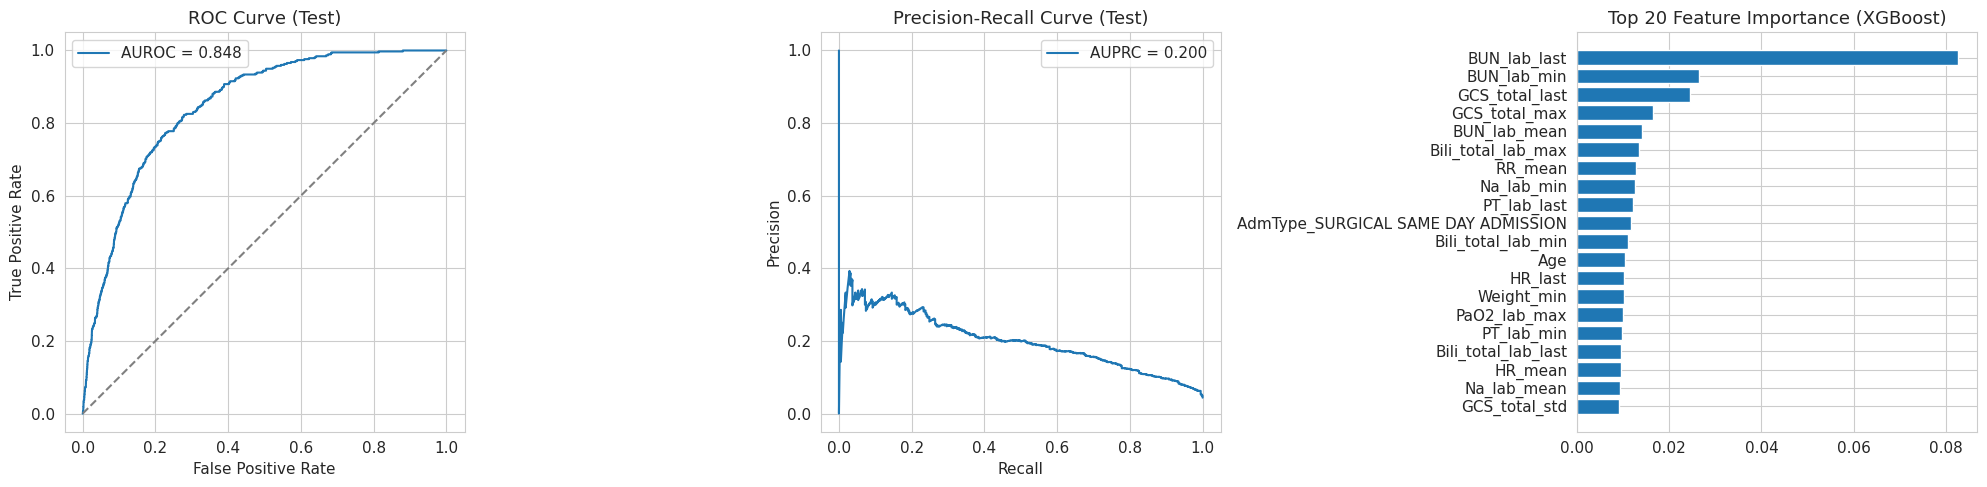

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_xgb, test_proba)
axes[0].plot(fpr, tpr, label=f"AUROC = {roc_auc_score(y_test_xgb, test_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (Test)")
axes[0].legend()

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test_xgb, test_proba)
axes[1].plot(rec, prec, label=f"AUPRC = {average_precision_score(y_test_xgb, test_proba):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (Test)")
axes[1].legend()

# Feature Importance (Top 20)
importance = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)
axes[2].barh(importance.index[::-1], importance.values[::-1])
axes[2].set_title("Top 20 Feature Importance (XGBoost)")

plt.tight_layout()
plt.show()

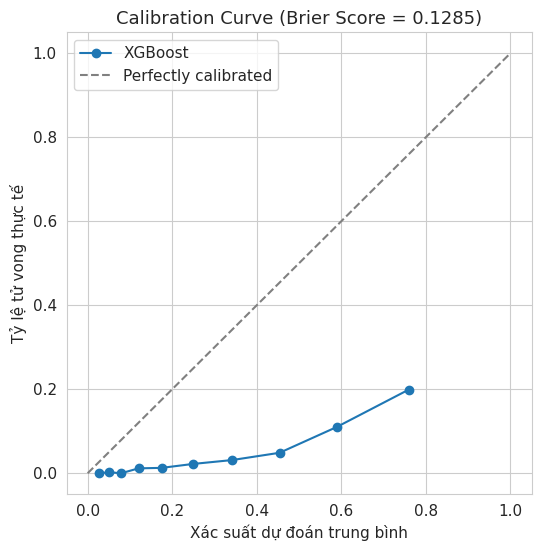

In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 6))
prob_true, prob_pred = calibration_curve(y_test_xgb, test_proba, n_bins=10, strategy="quantile")
ax.plot(prob_pred, prob_true, "o-", label="XGBoost")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Xác suất dự đoán trung bình")
ax.set_ylabel("Tỷ lệ tử vong thực tế")
ax.set_title(f"Calibration Curve (Brier Score = {brier_score_loss(y_test_xgb, test_proba):.4f})")
ax.legend()
plt.show()

In [ ]:
import numpy as np

def bootstrap_ci(y_true, y_proba, metric_func, n_bootstrap=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_func(y_true[idx], y_proba[idx]))
    return np.percentile(scores, [2.5, 50, 97.5])

auroc_ci = bootstrap_ci(y_test_xgb, test_proba, roc_auc_score)
auprc_ci = bootstrap_ci(y_test_xgb, test_proba, average_precision_score)
print(f"AUROC 95% CI: {auroc_ci[0]:.4f} - {auroc_ci[2]:.4f} (median {auroc_ci[1]:.4f})")
print(f"AUPRC 95% CI: {auprc_ci[0]:.4f} - {auprc_ci[2]:.4f} (median {auprc_ci[1]:.4f})")

AUROC 95% CI: 0.8303 - 0.8648 (median 0.8475)
AUPRC 95% CI: 0.1698 - 0.2372 (median 0.2023)


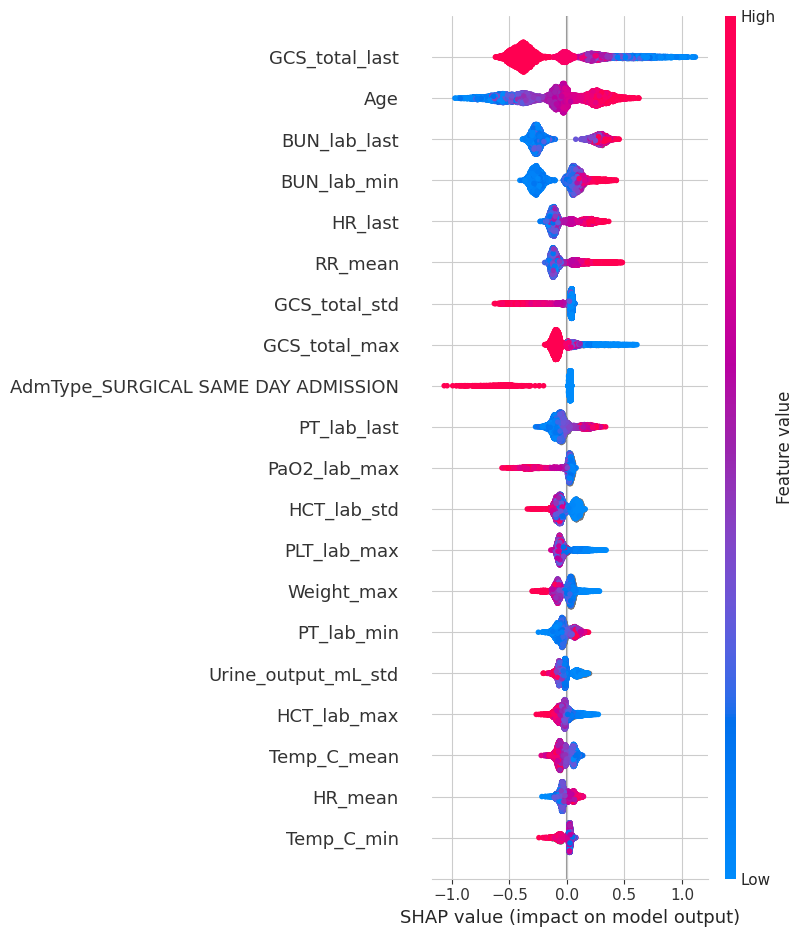

In [ ]:
# !pip install shap -q
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

shap.summary_plot(shap_values, X_test_xgb, max_display=20, show=True)

# 📋 Danh Sách Gợi Ý Cải Thiện Mô Hình XGBoost (Actionable Plan)

Dựa trên kết quả thử nghiệm hiện tại (AUROC = 0.848, AUPRC = 0.200, Brier Score = 0.1285), mô hình gặp 2 vấn đề lớn: **Mất cân bằng dữ liệu** và **Xác suất dự đoán bị phóng đại (Over-confident)**. Cần thực hiện các cải thiện sau cho các phiên bản tiếp theo:

---

### 1. 🎯 Hiệu Chỉnh Xác Suất Dự Đoán (Probability Calibration)
> **Mục tiêu:** Giảm Brier Score và kéo đường Calibration Curve tiệm cận đường chéo lý tưởng.

- [ ] **Thêm Post-processing Calibration:**
  - Áp dụng `CalibratedClassifierCV` của Scikit-Learn trên tập Validation.
  - Tối ưu bằng phương pháp **Isotonic Regression** (nếu dữ liệu đủ lớn) hoặc **Platt Scaling (Sigmoid)**.
- [ ] **Báo cáo lại chỉ số:** Lưu biểu đồ Calibration Curve và Brier Score trước vs. sau khi hiệu chỉnh.

---

### 2. ⚖️ Đổi Mới Cấu Hình Luyện Tập & Xử Lý Mất Cân Bằng (Imbalance Control)
> **Mục tiêu:** Cải thiện AUPRC (hiện tại 0.200) và tối ưu hóa điểm F1-Score/Recall.

- [ ] **Cấu hình Hyperparameter XGBoost:**
  - Thiết lập tham số `scale_pos_weight = (Số ca âm tính / Số ca dương tính)` trong XGBoost.
- [ ] **Thử nghiệm Kỹ thuật Resampling:**
  - Áp dụng **SMOTE** / **Random Under-sampling** trên duy nhất tập Training (không áp dụng lên Validation/Test).
- [ ] **Tối ưu Ngưỡng Quyết Định (Threshold Optimization):**
  - Thay vì dùng ngưỡng mặc định `0.5`, quét qua các ngưỡng từ `0.01` đến `0.99` trên tập Validation để chọn ngưỡng có điểm **F1-Score** hoặc **Youden's J Index** tốt nhất.

---

### 3. 🔍 Rà Soát Dữ Liệu & Rò Rỉ Dữ Liệu (Data Leakage Audit)
> **Mục tiêu:** Đảm bảo tính hợp lệ y khoa và độ tin cậy của các tính năng quan trọng nhất.

- [ ] **Kiểm tra mốc thời gian (Time-window Check):**
  - Đảm bảo các chỉ số có tầm ảnh hưởng lớn như `GCS_total_last` và `BUN_lab_last` chỉ được trích xuất nghiêm ngặt trong **24 giờ đầu**, không dính dữ liệu sát thời điểm tử vong/ra viện.
- [ ] **Xử lý Outliers & Missing Values:**
  - Thử nghiệm các phương pháp Imputation khác (MICE, KNN Imputer) thay vì để XGBoost tự xử lý NaN mặc định.

---

### 4. 📊 Phân Tích Chẩn Đoán & So Sánh Lâm Sàng (Evaluation & Benchmark)
> **Mục tiêu:** Tăng độ thuyết phục cho bài báo/báo cáo nghiên cứu.

- [ ] **So sánh với Thang điểm Lâm sàng:**
  - Tính AUROC/AUPRC của các thang điểm truyền thống như **SOFA**, **SAPS II**, hoặc **OASIS** trên cùng tập Test để làm Baseline so sánh.
- [ ] **Phân tích nhóm nhỏ (Subgroup Analysis):**
  - Đánh giá lại hiệu năng mô hình trên các nhóm bệnh nhân khác nhau:
    - Theo độ tuổi (ví dụ: $<65$ vs. $\ge 65$).
    - Theo loại nhập viện (`AdmType_SURGICAL...` vs. Nội khoa).
- [ ] **Xuất Confusion Matrix chi tiết:** Báo cáo các chỉ số *Sensitivity (Recall)*, *Specificity*, *PPV (Precision)*, và *NPV* tại ngưỡng tối ưu đã chọn.

Chưa loại các case OMR/dữ liệu quản lý hành chính bất thường (vd. admission_location = "DIED"), chưa kiểm tra trùng lặp subject_id do lỗi merge nhiều-nhiều với patients_df.

Rủi ro/điểm cần cải thiện:

- VALID_RANGE dùng chung một khoảng cho toàn bộ item — ví dụ FiO2 (0.1–1.05) áp dụng chung cho FiO2_lab, trong khi lab FiO2 (đơn vị %) đã được chuẩn hoá riêng ở cell 25, nhưng named key trong VALID_RANGE chỉ có "FiO2" chứ không có "FiO2_lab" → outlier filter không áp dụng được cho FiO2_lab vì tên biến không khớp. Đây là bug im lặng (silent bug) — không lỗi nhưng cũng không lọc gì cả. Nên rà lại toàn bộ key trong VALID_RANGE so với tên biến thực tế xuất hiện trong Variable để đảm bảo mọi biến đều được áp giới hạn.
- process_vasopressors/process_interventions dùng for _, r in chunk.iterrows() để "unroll" khoảng thời gian ra từng giờ — cực kỳ chậm với dữ liệu lớn (hàng trăm nghìn dòng inputevents). Nên vector hoá bằng np.repeat + pd.DataFrame thay vì iterrows, nhất là nếu định mở rộng sang toàn bộ MIMIC-IV (không chỉ sample).
- Không thấy xử lý trùng lặp đo lường trong cùng giờ với cùng itemid do lỗi nhập liệu (vd. y tá ghi 2 lần HR cách nhau vài phút) — hiện đang lấy trung bình cộng dồn qua val_sum/val_count, hợp lý, nhưng nên cân nhắc thêm median cho các biến dễ bị outlier đơn lẻ như Lactate, Creatinine
- Với các biến sinh hiệu (HR, SBP...) việc không đo được trong 1 giờ nào đó không có nghĩa là giá trị = 0 — bạn đã đúng khi không fillna(0) cho chúng, nhưng cần đảm bảo bước tổng hợp patient-level (aggregate_patient_features) xử lý NaN nhất quán khi tính mean/min/max/std (pandas mặc định bỏ NaN — ok), còn XGBoost sẽ tự học split trên missing (native NaN handling) — điều này chỉ đúng nếu bạn không impute trước khi đưa vào XGBoost. Notebook hiện không impute nên ổn, nhưng nên ghi chú tường minh lý do (nhiều reviewer sẽ hỏi "tại sao không impute?").

Tổng hợp patient-level & huấn luyện

Rủi ro quan trọng nhất trong toàn bộ pipeline:

Không có cross-validation, chỉ 1 lần train/val/test split cố định (random_state=42). Với cỡ mẫu MIMIC ICU mortality (~5–10% positive rate), một split đơn có thể dao động AUROC ±0.02–0.03 chỉ do may rủi chia dữ liệu. Để công bố kết quả đáng tin cậy, nên dùng ít nhất 5-fold hoặc repeated stratified CV (group theo PatientID) hoặc báo cáo CI qua nhiều random seed, không chỉ bootstrap trên 1 test set cố định.
Không có external validation (vd. eICU-CRD) — đây là rủi ro lớn nhất về mặt "generalization risk" cho một mô hình y khoa. Nội bộ AUROC cao trên MIMIC không đảm bảo transportability sang bệnh viện khác (khác biệt case-mix, thiết bị đo, coding). Nếu mục tiêu là "hạn chế rủi ro", đây là việc bắt buộc phải làm hoặc ít nhất phải nêu như limitation rõ ràng.
Không có baseline so sánh với các thang điểm lâm sàng chuẩn (SOFA, OASIS, SAPS-II, APACHE-II) hay ít nhất Logistic Regression đơn giản. Không có con số đối chứng thì không biết XGBoost "tốt hơn bao nhiêu" so với công cụ bác sĩ đang dùng thực tế — đây là điều bất kỳ reviewer y khoa nào cũng sẽ hỏi đầu tiên.
Hyperparameter cố định thủ công, không có tuning (grid/optuna) trên validation — nên ít nhất chạy random search nhỏ để tránh underfitting/overfitting ngẫu nhiên do chọn tay.
Chưa phân tích theo subgroup (tuổi, giới tính, admission_type, chủng tộc nếu có) — công bằng thuật toán (algorithmic fairness) là yêu cầu tối thiểu cho mô hình dự đoán tử vong trước khi cân nhắc dùng thử lâm sàng.
Threshold chọn theo Youden's J tối ưu hoá TPR-FPR — hợp lý cho nghiên cứu, nhưng trong bối cảnh lâm sàng thực tế với positive rate thấp, nên báo cáo thêm threshold theo Precision-Recall (vì AUPRC informative hơn AUROC khi mất cân bằng) và ít nhất 1 threshold ưu tiên độ đặc hiệu cao (giảm false alarm).